In [27]:
from langgraph.graph import StateGraph, END, START
from typing import TypedDict, List, Dict
from langchain_google_genai import ChatGoogleGenerativeAI
from pydantic import BaseModel
import os

In [10]:
from dotenv import load_dotenv
load_dotenv()
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")

llm = ChatGoogleGenerativeAI(
    model="gemini-3-flash-preview",
    temperature=0
)

In [ ]:
#res = llm.invoke("what is data?")

In [ ]:
#res.content[0]['text']

'At its simplest level, **data is a collection of raw facts, observations, or symbols.**\n\nThink of data as the "building blocks" of information. On its own, a single piece of data often doesn\'t mean much. It is only when data is organized, processed, and interpreted that it becomes **information**.\n\nHere is a breakdown of what data is, how it’s categorized, and why it matters.\n\n---\n\n### 1. The "Cake" Analogy\nTo understand data, think of baking a cake:\n*   **Data:** The raw ingredients (flour, eggs, sugar, milk). Individually, they aren\'t a meal.\n*   **Processing:** The act of mixing and baking.\n*   **Information:** The finished cake. It is the result of organizing the raw ingredients into something useful.\n\n### 2. Types of Data\nData is generally divided into two main categories:\n\n#### **A. Quantitative Data (Numbers)**\nThis is data that can be measured or counted.\n*   **Examples:** Your height, the price of a loaf of bread, the temperature outside, or the number of

In [15]:
class AgentState(TypedDict):
    query: str
    service: str
    task: str
    sources: List[str]
    documents: List[str]
    parsed_data: Dict
    verified_data: Dict
    final_answer: str

In [16]:
class QuerySchema(BaseModel):
    service: str
    task: str
    entity: str

In [17]:
class ParsedSchema(BaseModel):
    steps: List[str]
    documents_required: List[str]
    portal: str

In [18]:
class VerifySchema(BaseModel):
    verified: bool
    confidence_score: float

In [19]:
def query_understanding(state: AgentState):

    structured_llm = llm.with_structured_output(QuerySchema)

    result = structured_llm.invoke(
        f"""
        Extract government service information.

        Query: {state["query"]}

        Identify:
        - service
        - task
        - entity
        """
    )

    return {
        "service": result.service,
        "task": result.task
    }

In [32]:
class SourceSchema(BaseModel):
    sources: List[str]
    
def source_selector(state: AgentState):

    structured_llm = llm.with_structured_output(SourceSchema)

    result = structured_llm.invoke(
        f"""
        Identify official Indian government websites for this service.

        Service: {state["service"]}

        Only return official portals like:
        gov.in
        nic.in
        """
    )

    return {
        "sources": result.sources
    }

In [21]:
def deep_research(state: AgentState):

    docs = [
        f"Information about {state['service']} from {s}"
        for s in state["sources"]
    ]

    return {
        "documents": docs
    }

In [22]:
def document_parser(state: AgentState):

    structured_llm = llm.with_structured_output(ParsedSchema)

    result = structured_llm.invoke(
        f"""
        Extract steps and required documents.

        Documents:
        {state["documents"]}
        """
    )

    return {
        "parsed_data": result.dict()
    }

In [23]:
def verification_agent(state: AgentState):

    structured_llm = llm.with_structured_output(VerifySchema)

    result = structured_llm.invoke(
        f"""
        Verify this information from government sources.

        Data:
        {state["parsed_data"]}
        """
    )

    return {
        "verified_data": result.dict()
    }

In [25]:
def response_generation(state: AgentState):

    response = llm.invoke(
        f"""
        Generate a clear answer for the user.

        Query:
        {state["query"]}

        Verified Data:
        {state["parsed_data"]}

        Provide steps and documents required.
        """
    )

    return {
        "final_answer": response.content
    }

In [26]:
builder = StateGraph(AgentState)

builder.add_node("query_understanding", query_understanding)
builder.add_node("source_selector", source_selector)
builder.add_node("deep_research", deep_research)
builder.add_node("document_parser", document_parser)
builder.add_node("verification_agent", verification_agent)
builder.add_node("response_generation", response_generation)

In [28]:
builder.add_edge(START, "query_understanding")

builder.add_edge("query_understanding", "source_selector")

builder.add_edge("source_selector", "deep_research")

builder.add_edge("deep_research", "document_parser")

builder.add_edge("document_parser", "verification_agent")

builder.add_edge("verification_agent", "response_generation")

builder.add_edge("response_generation", END)

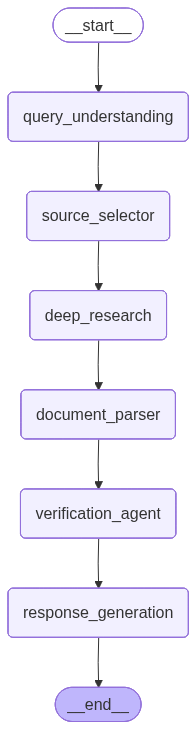

In [30]:
app = builder.compile()
app

In [33]:
result = app.invoke({
    "query": "How to update PAN address?"
})

print(result["final_answer"])

C:\Users\karti\AppData\Local\Temp\ipykernel_18752\2763957590.py:15: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  "parsed_data": result.dict()


[{'type': 'text', 'text': "To update the address on your PAN card, you can use the official Income Tax e-Filing portal. The process is primarily driven by your Aadhaar details.\n\n### **Steps to Update PAN Address**\n\n1.  **Visit the Portal:** Go to the official Income Tax e-Filing website: [https://eportal.incometax.gov.in](https://eportal.incometax.gov.in).\n2.  **Select Option:** Look for and select the **'Instant e-PAN'** or **'Apply for PAN'** option.\n3.  **Aadhaar Authentication:** Enter your **Aadhaar number**. You will receive an **OTP** on the mobile number registered with your Aadhaar; enter this to validate your identity.\n4.  **Verify Details:** Fill in or verify your personal details. Since the system pulls information from the Aadhaar database, ensure your Aadhaar has the correct updated address.\n5.  **Submit:** Submit the application. You can then download the updated e-PAN or track the status of your physical card delivery.\n\n---\n\n### **Documents Required**\n\nTo 